# Baseline Experiments Overview

We trained three independent BERT-based baselines to cover all key subtasks in our study:

1. **PAN25 (Binary):**  
   Human vs AI text classification to measure general separability between natural and generated text.

2. **PAN25 (Multi-Class):**  
   Identification of *which* language model produced a text (e.g., GPT-3.5, GPT-4, etc.).  
   This tests fine-grained stylistic discrimination across different generators.

3. **AuthorMix (Multi-Class):**  
   Authorship / style classification across human authors (as used in the StyleRemix paper).  
   Serves as a benchmark for stylistic representation learning and interpretability studies.

All runs use `bert-base-uncased`, max_length=256, a seed sweep, and report accuracy + macro/micro/weighted F1. Multiclass runs use class-weighted loss.

In [ ]:
!pip -q install -U pip
!pip -q install --upgrade --no-cache-dir \
  "numpy<2" \
  "pandas==2.2.2" \
  "scikit-learn==1.5.2" \
  "scipy==1.12.0" \
  transformers datasets accelerate captum matplotlib

!pip -q install --upgrade --no-cache-dir torchvision --index-url https://download.pytorch.org/whl/cu128

import os
os.kill(os.getpid(), 9)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BAR"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

Mounted at /content/drive


In [ ]:
import os, json, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments, set_seed
)
import time
from transformers import DataCollatorWithPadding
from collections import Counter
from captum.attr import LayerIntegratedGradients, LayerGradientShap

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE: cuda
GPU: Tesla T4


## PAN25 — Binary Classification (0/1)
**Data**: `pan25/train.jsonl` → stratified split (train/val/test)  
**Target**: `label ∈ {0,1}`  
**Model**: `bert-base-uncased`, `num_labels=2`  
**Trainer**: standard `Trainer`  
**Seeds**: `[11, 18, 2022]`  
**Metrics**: accuracy, macro-F1, weighted-F1 (per seed + mean/std)  
**Output**: per-seed table, summary, best seed

In [ ]:
ROOT = "/content/drive/MyDrive/ap-thesis"
RUNS_ROOT = f"{ROOT}/runs"

os.makedirs(f"{RUNS_ROOT}/results", exist_ok=True)
os.makedirs(f"{RUNS_ROOT}/models", exist_ok=True)

BASE_MODEL = "bert-base-uncased"
SEEDS = [11, 18, 2022]

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
pan_path_drive = f"{ROOT}/data/pan25/train.jsonl"
assert os.path.exists(pan_path_drive), f"Not found: {pan_path_drive}"

pan_path = "/content/train.jsonl"
!cp "{pan_path_drive}" "{pan_path}"

with open(pan_path, "r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in f]

df_pan = pd.DataFrame(rows)

assert {"text", "label"}.issubset(df_pan.columns), "Expected columns: text, label"
assert set(df_pan["label"].unique()) <= {0, 1}, "PAN25 label must be 0/1"

df_train, df_tmp = train_test_split(
    df_pan, test_size=0.30, random_state=42, stratify=df_pan["label"]
)
df_val, df_test = train_test_split(
    df_tmp, test_size=0.50, random_state=42, stratify=df_tmp["label"]
)

def to_ds(df: pd.DataFrame) -> Dataset:
    return Dataset.from_pandas(df[["text", "label"]].reset_index(drop=True), preserve_index=False)

pan_ds = DatasetDict(
    train=to_ds(df_train),
    validation=to_ds(df_val),
    test=to_ds(df_test),
)

In [ ]:
start = time.time()
pan_ds_tok = pan_ds.map(
    tokenize_fn,
    batched=True,
    remove_columns=["text"],
    num_proc=1,   # 2-4
    desc="Tokenizing PAN25",
)
print(f"Tokenization took {time.time() - start:.2f} seconds")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Train/Val/Test sizes:",
      len(pan_ds_tok["train"]),
      len(pan_ds_tok["validation"]),
      len(pan_ds_tok["test"]))
print("Columns:", pan_ds_tok["train"].column_names)
print("Example keys:", pan_ds_tok["train"][0].keys())

Tokenizing PAN25 (num_proc=1):   0%|          | 0/16594 [00:00<?, ? examples/s]

Tokenizing PAN25 (num_proc=1):   0%|          | 0/3556 [00:00<?, ? examples/s]

Tokenizing PAN25 (num_proc=1):   0%|          | 0/3557 [00:00<?, ? examples/s]

Tokenization took 90.38 seconds
Train/Val/Test sizes: 16594 3556 3557
Columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Example keys: dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])


In [ ]:
def make_args_compat(output_dir, seed, lr=2e-5, epochs=3,
                     train_bs=8, eval_bs=16, grad_acc=2, metric="f1_macro"):
    kwargs_common = dict(
        output_dir=output_dir,
        learning_rate=lr,
        per_device_train_batch_size=train_bs,
        per_device_eval_batch_size=eval_bs,
        gradient_accumulation_steps=grad_acc,
        num_train_epochs=epochs,
        logging_steps=50,
        report_to="none",
        seed=seed,
        fp16=(DEVICE=="cuda"),  # good on T4
    )
    try:
        return TrainingArguments(
            **kwargs_common,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model=metric,
        )
    except TypeError:
        return TrainingArguments(**kwargs_common)

def run_pan25_one_seed(seed):
    set_seed(seed)
    model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=2)
    model.to(DEVICE)

    args = make_args_compat(output_dir=f"{RUNS_ROOT}/bert_aa_pan25_seed{seed}", seed=seed)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=pan_ds_tok["train"],
        eval_dataset=pan_ds_tok["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    print("Trainer device:", trainer.args.device)

    trainer.train()
    test_metrics = {k: float(v) for k, v in trainer.evaluate(pan_ds_tok["test"]).items()}
    return test_metrics, trainer

In [ ]:
pan_rows = []
best = {"seed": None, "f1": -1, "trainer": None}

for s in SEEDS:
    print(f"\n/// PAN25 binary — seed {s}")
    m, tr = run_pan25_one_seed(s)
    pan_rows.append({"seed": s, **m})
    if m.get("eval_f1_macro", -1) > best["f1"]:
        best = {"seed": s, "f1": m["eval_f1_macro"], "trainer": tr}

pan_df = pd.DataFrame(pan_rows).sort_values("eval_f1_macro", ascending=False)
pan_summary = pan_df.agg({
    "eval_accuracy":["mean","std"],
    "eval_f1_macro":["mean","std"],
    "eval_f1_weighted":["mean","std"]
})

display(pan_df); display(pan_summary)

pan_df.to_csv(f"{RUNS_ROOT}/results/pan25_binary_seeds.csv", index=False)
print("Saved:", f"{RUNS_ROOT}/results/pan25_binary_seeds.csv")


/// PAN25 binary — seed 11


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer device: cuda:0


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

,seed,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,11,0.040543,0.99016,0.989630,0.990174,14.2940,248.846,15.601,3.0
2,2022,0.046831,0.99016,0.989625,0.990172,14.4198,246.674,15.465,3.0
1,18,0.077329,0.98510,0.984347,0.985143,15.0819,235.845,14.786,3.0


,eval_accuracy,eval_f1_macro,eval_f1_weighted
mean,0.988473,0.987867,0.988496
std,0.002922,0.003049,0.002904


Saved: /content/drive/MyDrive/ap-thesis/runs/results/pan25_binary_seeds.csv


In [ ]:
best_bin_dir = f"{RUNS_ROOT}/models/pan25_binary_best_seed{best['seed']}"
os.makedirs(best_bin_dir, exist_ok=True)
best["trainer"].save_model(best_bin_dir)
tokenizer.save_pretrained(best_bin_dir)
print("Saved best binary model to:", best_bin_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best binary model to: /content/drive/MyDrive/ap-thesis/runs/models/pan25_binary_best_seed11


In [ ]:
pan_tok_dir = f"{ROOT}/cache/pan25_binary_tok_bert256"
os.makedirs(f"{ROOT}/cache", exist_ok=True)
pan_ds_tok.save_to_disk(pan_tok_dir)
print("Saved tokenized dataset to:", pan_tok_dir)

Saving the dataset (0/1 shards):   0%|          | 0/16594 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3556 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3557 [00:00<?, ? examples/s]

Saved tokenized dataset to: /content/drive/MyDrive/ap-thesis/cache/pan25_binary_tok_bert256


## PAN25 — Multi-Classification (Class)
**Target**: `model` (LabelEncoder → `label_mc`)  
**Classes**: `num_labels_mc = len(le_mc.classes_)`  
**Trainer**: `WeightedTrainer` (class-weighted CE)  
**Seeds**: `[11, 18, 2022]`  
**Metrics**: accuracy, macro-F1, weighted-F1, confusion matrix  
**Notes**: Imbalance handled with class weights; report per-seed + summary; show confusion matrix for best seed.

In [ ]:
assert "model" in df_train.columns, "PAN multiclass needs a 'model' column in the dataset."

df_train_mc = df_train.copy()
df_val_mc   = df_val.copy()
df_test_mc  = df_test.copy()

le_mc = LabelEncoder()
le_mc.fit(pd.concat([df_train_mc["model"], df_val_mc["model"], df_test_mc["model"]]))

df_train_mc["label_mc"] = le_mc.transform(df_train_mc["model"])
df_val_mc["label_mc"]   = le_mc.transform(df_val_mc["model"])
df_test_mc["label_mc"]  = le_mc.transform(df_test_mc["model"])

num_labels_mc = len(le_mc.classes_)
print("num_labels_mc:", num_labels_mc)

def to_ds_mc(df):
    return Dataset.from_pandas(
        df[["text","label_mc"]].rename(columns={"label_mc":"label"}).reset_index(drop=True),
        preserve_index=False
    )

pan_mc = DatasetDict({
    "train": to_ds_mc(df_train_mc),
    "validation": to_ds_mc(df_val_mc),
    "test": to_ds_mc(df_test_mc),
})

pan_mc_tok = pan_mc.map(tokenize_fn, batched=True, remove_columns=["text"], num_proc=1)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

num_labels_mc: 23


Map (num_proc=1):   0%|          | 0/16594 [00:00<?, ? examples/s]

Map (num_proc=1):   0%|          | 0/3556 [00:00<?, ? examples/s]

Map (num_proc=1):   0%|          | 0/3557 [00:00<?, ? examples/s]

In [ ]:
cnt = Counter(df_train_mc["label_mc"].tolist())
weights = torch.tensor([len(df_train_mc)/cnt[c] for c in range(num_labels_mc)], dtype=torch.float)
if DEVICE != "cpu":
    weights = weights.to(DEVICE)

import torch.nn.functional as F
from transformers import Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels", None)
        if labels is None and "label" in inputs:
            labels = inputs["label"]
        model_inputs = {k: v for k, v in inputs.items() if k not in ["labels", "label"]}
        outputs = model(**model_inputs)
        loss = F.cross_entropy(outputs.logits, labels, weight=weights)
        return (loss, outputs) if return_outputs else loss

def run_pan25_multiclass_one_seed(seed):
    set_seed(seed)
    model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=num_labels_mc)
    model.to(DEVICE)

    args = make_args_compat(output_dir=f"{RUNS_ROOT}/bert_aa_pan25_multiclass_seed{seed}", seed=seed)

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=pan_mc_tok["train"],
        eval_dataset=pan_mc_tok["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    print("Trainer device:", trainer.args.device)
    trainer.train()
    test_metrics = {k: float(v) for k, v in trainer.evaluate(pan_mc_tok["test"]).items()}
    return test_metrics, trainer

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds), # added
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

In [ ]:
mc_rows = []
best_mc = {"seed": None, "f1": -1, "trainer": None}

for s in SEEDS:
    print(f"\n/// PAN25 MULTICLASS — seed {s}")
    m, tr = run_pan25_multiclass_one_seed(s)
    mc_rows.append({"seed": s, **m})
    if m.get("eval_f1_macro", -1) > best_mc["f1"]:
        best_mc = {"seed": s, "f1": m["eval_f1_macro"], "trainer": tr}

mc_df = pd.DataFrame(mc_rows).sort_values("eval_f1_macro", ascending=False)
display(mc_df)

mc_df.to_csv(f"{RUNS_ROOT}/results/pan25_multiclass_seeds.csv", index=False)
print("Saved:", f"{RUNS_ROOT}/results/pan25_multiclass_seeds.csv")


/// PAN25 MULTICLASS — seed 11


BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer device: cuda:0


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
1,3.705102,1.836486,0.591114,0.401073,0.343692,0.572726
2,2.669937,1.726758,0.604331,0.435438,0.378698,0.594217
3,1.969846,1.468057,0.642013,0.506093,0.455357,0.644153


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

...

Trainer device: cuda:0


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
1,3.509615,1.745172,0.598425,0.400824,0.352558,0.597855
2,2.387023,1.643618,0.571429,0.446427,0.395192,0.584016
3,1.925729,1.435566,0.646794,0.509658,0.458731,0.655396


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

,seed,eval_loss,eval_accuracy,eval_balanced_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
1,18,1.373564,0.672196,0.540778,0.495837,0.673070,14.9609,237.753,14.906,3.0
2,2022,1.380944,0.660669,0.542343,0.486434,0.665898,14.5845,243.889,15.290,3.0
0,11,1.411676,0.642958,0.522771,0.470992,0.642689,13.8797,256.274,16.067,3.0


Saved: /content/drive/MyDrive/ap-thesis/runs/results/pan25_multiclass_seeds.csv


In [ ]:
best_mc_dir = f"{RUNS_ROOT}/models/pan25_multiclass_best_seed{best_mc['seed']}"
os.makedirs(best_mc_dir, exist_ok=True)

best_mc["trainer"].save_model(best_mc_dir)
tokenizer.save_pretrained(best_mc_dir)

print("Saved best multiclass model to:", best_mc_dir)
print("Best seed:", best_mc["seed"], "Best macro-F1:", round(best_mc["f1"], 4))

Saved best multiclass model to: /content/drive/MyDrive/ap-thesis/runs/models/pan25_multiclass_best_seed18
Best seed: 18 Best macro-F1: 0.4958


In [ ]:
major = df_train_mc["label_mc"].value_counts().idxmax()
baseline_acc = (df_test_mc["label_mc"] == major).mean()

In [ ]:
df_pan["model"].nunique()

23

**23-class classification**

Anything above ~10 classes in text classification is non-trivial, especially stylistic / generator attribution.

In [ ]:
df_pan["label"].nunique(), df_pan["label"].value_counts().head(20)

(2,
 label
 1    14606
 0     9101
 Name: count, dtype: int64)

In [ ]:
counts = df_train_mc["label_mc"].value_counts()
print(counts.describe())
print("min/max:", counts.min(), counts.max())


count      23.000000
mean      721.478261
std      1268.447364
min       182.000000
25%       189.500000
50%       283.000000
75%       747.500000
max      6370.000000
Name: count, dtype: float64
min/max: 182 6370


Very strong imbalance explains accuracy ≈ 0.63, macro-F1 ≈ 0.50:

*  frequent generators learned well
*  rare generators confused
*  macro-F1 punished heavily

*baseline acc = 0.384* confirms this:

In [ ]:
baseline_acc

0.38403148720832164

In [ ]:
lens = df_train_mc["text"].str.split().str.len()
print(lens.describe())


count    16594.000000
mean       622.111305
std        209.490763
min         56.000000
25%        489.000000
50%        636.000000
75%        715.000000
max       4892.000000
Name: text, dtype: float64



*  more than half of every document is thrown away.
*  for many samples, we see only ~40% of the text
*  stylistic signal later in the text is lost

→ increasing max_length from 256 to 512. Although truncation is commonly used for efficiency, it substantially limits performance in long-document stylistic classification. Increasing the input length enables the model to access more global stylistic cues, leading to improved macro-F1.

In [ ]:
def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=512)

# re-tokenization (ignore old cache)
pan_mc_tok = pan_mc.map(
    tokenize_fn,
    batched=True,
    remove_columns=["text"],
    num_proc=1,
    load_from_cache_file=False,   # <- key line
    desc="Tokenizing PAN25 multiclass (512)",
)

from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# lengths change
ex = pan_mc_tok["train"][0]["input_ids"]
print("Example token length:", len(ex))
print("Columns:", pan_mc_tok["train"].column_names)

Tokenizing PAN25 multiclass (512) (num_proc=1):   0%|          | 0/16594 [00:00<?, ? examples/s]

Tokenizing PAN25 multiclass (512) (num_proc=1):   0%|          | 0/3556 [00:00<?, ? examples/s]

Tokenizing PAN25 multiclass (512) (num_proc=1):   0%|          | 0/3557 [00:00<?, ? examples/s]

Example token length: 512
Columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
print("Avg train token length (first 200):",
      np.mean([len(pan_mc_tok["train"][i]["input_ids"]) for i in range(200)]))
print("Max in first 200:",
      np.max([len(pan_mc_tok["train"][i]["input_ids"]) for i in range(200)]))

Avg train token length (first 200): 503.87
Max in first 200: 512


In [ ]:
mc_rows = []
best_mc = {"seed": None, "f1": -1, "trainer": None}

for s in SEEDS:
    print(f"\n/// PAN25 MULTICLASS — seed {s}")
    m, tr = run_pan25_multiclass_one_seed(s)
    mc_rows.append({"seed": s, **m})
    if m.get("eval_f1_macro", -1) > best_mc["f1"]:
        best_mc = {"seed": s, "f1": m["eval_f1_macro"], "trainer": tr}

mc_df = pd.DataFrame(mc_rows).sort_values("eval_f1_macro", ascending=False)
display(mc_df)

mc_df.to_csv(f"{RUNS_ROOT}/results/pan25_multiclass_seeds.csv", index=False)
print("Saved:", f"{RUNS_ROOT}/results/pan25_multiclass_seeds.csv")


/// PAN25 MULTICLASS — seed 11


BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer device: cuda:0


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
1,3.299096,1.689430,0.595332,0.412122,0.352583,0.577522
2,2.209774,1.393768,0.688414,0.501161,0.463278,0.676252
3,1.483130,1.200372,0.717379,0.575116,0.537245,0.717049


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

...

Trainer device: cuda:0


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
1,3.125040,1.578508,0.634702,0.471183,0.414022,0.632875
2,2.035874,1.389910,0.671260,0.525422,0.481510,0.675418
3,1.539196,1.162585,0.722160,0.585906,0.546429,0.727509


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

,seed,eval_loss,eval_accuracy,eval_balanced_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
2,2022,1.134111,0.734889,0.622646,0.577158,0.737163,31.6530,112.375,7.045,3.0
1,18,1.103799,0.741074,0.617459,0.575954,0.738554,31.4865,112.969,7.082,3.0
0,11,1.167066,0.719145,0.605403,0.563017,0.717705,32.0442,111.003,6.959,3.0


Saved: /content/drive/MyDrive/ap-thesis/runs/results/pan25_multiclass_seeds.csv


In [ ]:
best_mc_dir = f"{RUNS_ROOT}/models/pan25_multiclass_best_seed{best_mc['seed']}"
os.makedirs(best_mc_dir, exist_ok=True)

best_mc["trainer"].save_model(best_mc_dir)   # model + config
tokenizer.save_pretrained(best_mc_dir)       # tokenizer files

print("Saved best multiclass model to:", best_mc_dir)
print("Best seed:", best_mc["seed"], "Best macro-F1:", round(best_mc["f1"], 4))

Saved best multiclass model to: /content/drive/MyDrive/ap-thesis/runs/models/pan25_multiclass_best_seed2022
Best seed: 2022 Best macro-F1: 0.5772


Saved tokenized multiclass dataset to: /content/drive/MyDrive/ap-thesis/runs/cache/pan25_multiclass_tok512


Saved label map to: /content/drive/MyDrive/ap-thesis/runs/models/pan25_multiclass_label_map.json

Best seed: 2022 Best macro-F1: 0.5772
Test size: 3557
Num classes: 23


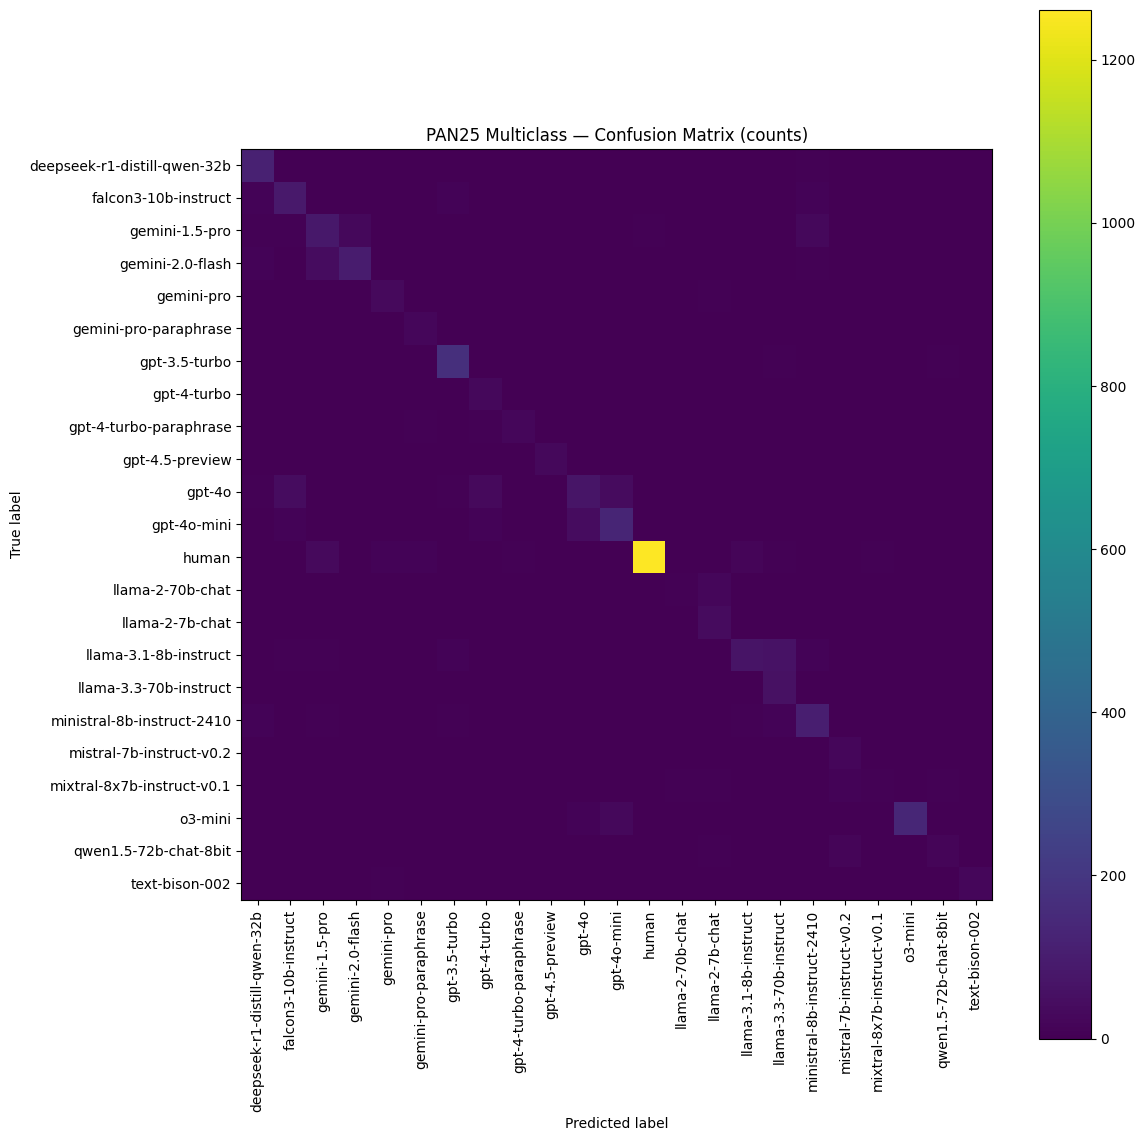

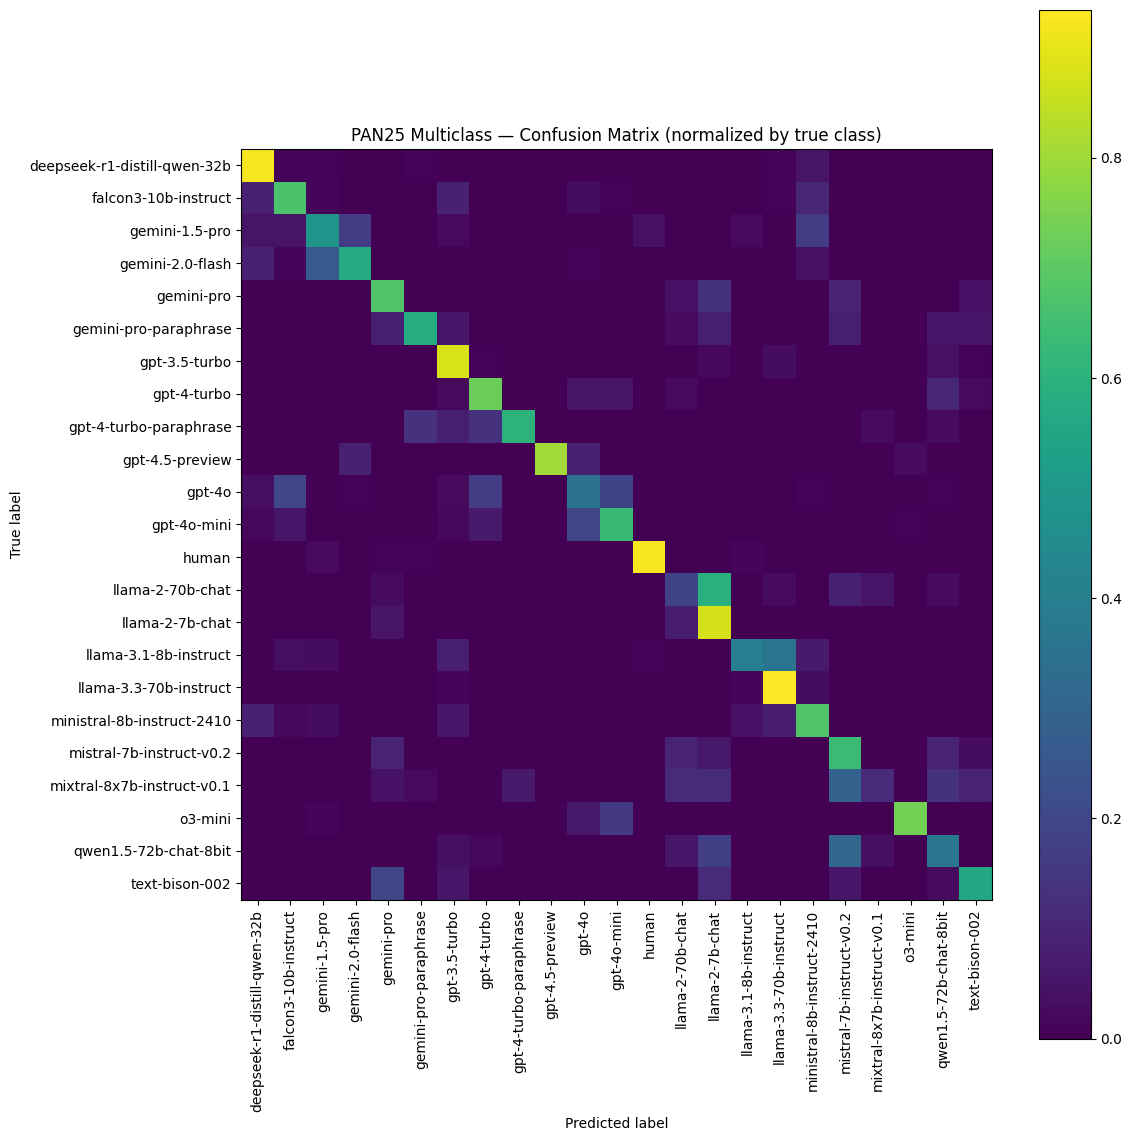

Saved confusion matrix images to: /content/drive/MyDrive/ap-thesis/runs/results/


In [ ]:
pred = best_mc["trainer"].predict(pan_mc_tok["test"])

y_true = pred.label_ids
y_pred = pred.predictions.argmax(axis=-1)

print("Best seed:", best_mc["seed"], "Best macro-F1:", round(best_mc["f1"], 4))
print("Test size:", len(y_true))
print("Num classes:", len(le_mc.classes_))

os.makedirs(f"{RUNS_ROOT}/results", exist_ok=True)

names = list(le_mc.classes_)
labels = np.arange(len(names))

cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

# Counts
plt.figure(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names)
disp.plot(include_values=False, xticks_rotation=90, ax=plt.gca())
plt.title("PAN25 Multiclass — Confusion Matrix (counts)")
plt.tight_layout()
plt.savefig(f"{RUNS_ROOT}/results/pan25_multiclass_confusion_counts_seed{best_mc['seed']}.png", dpi=200)
plt.show()

# Normalized by true class (row-normalized)
plt.figure(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=names)
disp.plot(include_values=False, xticks_rotation=90, ax=plt.gca())
plt.title("PAN25 Multiclass — Confusion Matrix (normalized by true class)")
plt.tight_layout()
plt.savefig(f"{RUNS_ROOT}/results/pan25_multiclass_confusion_norm_seed{best_mc['seed']}.png", dpi=200)
plt.show()

print("Saved confusion matrix images to:", f"{RUNS_ROOT}/results/")


The confusion matrix reveals that most errors occur between closely related model variants (e.g., GPT-4 family, Gemini variants, LLaMA/Mistral family), while predictions remain well-aligned along the diagonal. This indicates that the classifier captures high-level stylistic similarities between model families but struggles with fine-grained distinctions among closely related generators. Notably, the human class remains clearly separable from generated text.

,class,precision,recall,f1,support
19,mixtral-8x7b-instruct-v0.1,0.333333,0.113636,0.169492,44.0
13,llama-2-70b-chat,0.241379,0.189189,0.212121,37.0
21,qwen1.5-72b-chat-8bit,0.387755,0.365385,0.376238,52.0
10,gpt-4o,0.529851,0.351485,0.422619,202.0
18,mistral-7b-instruct-v0.2,0.328125,0.636364,0.432990,33.0
7,gpt-4-turbo,0.345238,0.725000,0.467742,40.0
2,gemini-1.5-pro,0.473684,0.482143,0.477876,168.0
15,llama-3.1-8b-instruct,0.690722,0.401198,0.507576,167.0
14,llama-2-7b-chat,0.384615,0.875000,0.534351,40.0
5,gemini-pro-paraphrase,0.511628,0.578947,0.543210,38.0


Saved per-class report to: /content/drive/MyDrive/ap-thesis/runs/results/pan25_multiclass_per_class_report_seed2022.csv


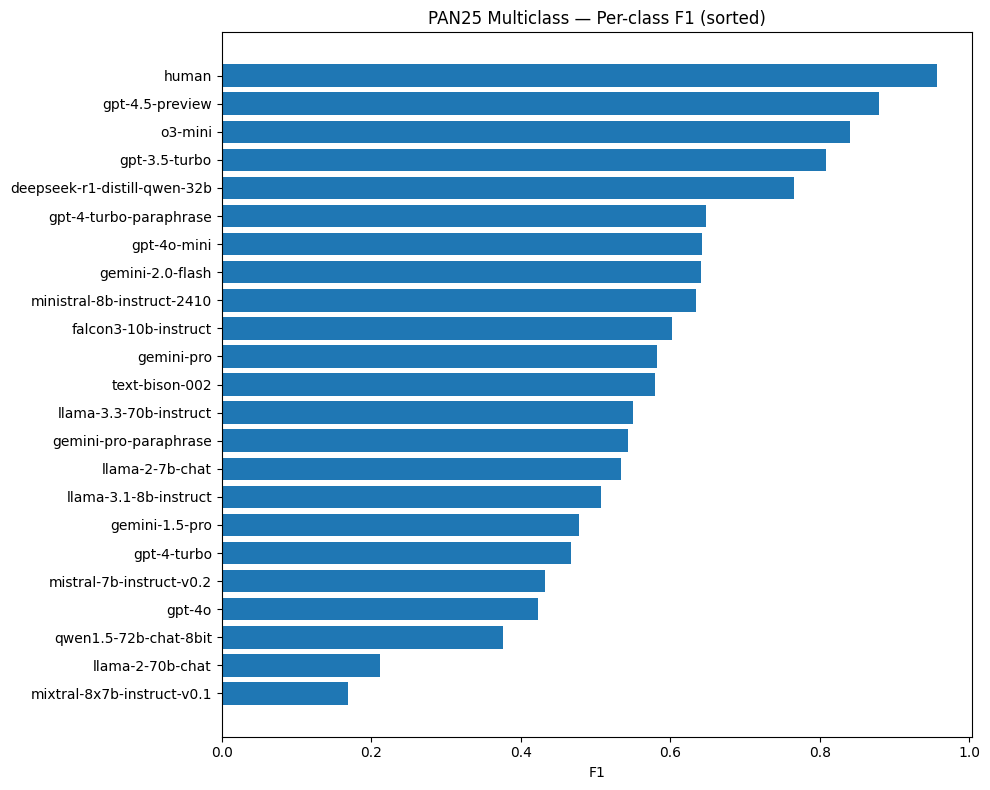

In [ ]:
from sklearn.metrics import classification_report
report = classification_report(
    y_true, y_pred,
    target_names=names,
    output_dict=True,
    zero_division=0
)

df_rep = pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})

df_classes = df_rep[df_rep["class"].isin(names)].copy()
df_classes = df_classes.rename(columns={"f1-score": "f1"})
df_classes = df_classes.sort_values("f1", ascending=True)

display(df_classes[["class", "precision", "recall", "f1", "support"]])

out_csv = f"{RUNS_ROOT}/results/pan25_multiclass_per_class_report_seed{best_mc['seed']}.csv"
df_classes.to_csv(out_csv, index=False)
print("Saved per-class report to:", out_csv)

plt.figure(figsize=(10, 8))
plt.barh(df_classes["class"], df_classes["f1"])
plt.title("PAN25 Multiclass — Per-class F1 (sorted)")
plt.xlabel("F1")
plt.tight_layout()
plt.savefig(f"{RUNS_ROOT}/results/pan25_multiclass_per_class_f1_seed{best_mc['seed']}.png", dpi=200)
plt.show()

In [ ]:
pairs = []
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0:
            pairs.append({
                "true_class": names[i],
                "pred_class": names[j],
                "count": int(cm[i, j]),
                "row_frac": float(cm_norm[i, j])  # fraction of true class i predicted as j
            })

df_conf = pd.DataFrame(pairs).sort_values(["count", "row_frac"], ascending=False)

display(df_conf.head(25))

out_csv = f"{RUNS_ROOT}/results/pan25_multiclass_top_confusions_seed{best_mc['seed']}.csv"
df_conf.to_csv(out_csv, index=False)
print("Saved top confusions to:", out_csv)

,true_class,pred_class,count,row_frac
104,llama-3.1-8b-instruct,llama-3.3-70b-instruct,60,0.359281
22,gemini-2.0-flash,gemini-1.5-pro,43,0.260606
60,gpt-4o,falcon3-10b-instruct,40,0.198020
73,gpt-4o-mini,gpt-4o,40,0.195122
65,gpt-4o,gpt-4o-mini,38,0.188119
64,gpt-4o,gpt-4-turbo,33,0.163366
76,human,gemini-1.5-pro,31,0.022694
136,o3-mini,gpt-4o-mini,29,0.160221
14,gemini-1.5-pro,gemini-2.0-flash,28,0.166667
19,gemini-1.5-pro,ministral-8b-instruct-2410,27,0.160714


Saved top confusions to: /content/drive/MyDrive/ap-thesis/runs/results/pan25_multiclass_top_confusions_seed2022.csv


## AuthorMix — Multiclass (Style)
**Files**: `AuthorMix-train.json`, `AuthorMix-val.json`, `AuthorMix-test.json`  
**Columns**: `text`, `style`, `category`  
**Target**: `style` (LabelEncoder → `label`), `num_labels = len(le.classes_)`  
**Trainer**: `WeightedTrainer` (class-weighted CE)  
**Seeds**: `[13, 42, 2025]`  
**Metrics**: accuracy, macro-F1, weighted-F1; confusion matrix; per-category scores (`author/blog/amt`)  
**Interpretation**: `amt` macro-F1 is typically lower due to many low-support classes → macro average penalizes rare classes.

In [ ]:
AUTHORMIX_DIR = f"{ROOT}/data/style-remix/AuthorMix"  # adjust if needed
assert os.path.exists(AUTHORMIX_DIR), f"Not found: {AUTHORMIX_DIR}"

# Optional speed-up: copy to local disk (faster than Drive I/O)
LOCAL_AUTHORMIX_DIR = "/content/AuthorMix"
!rm -rf "{LOCAL_AUTHORMIX_DIR}"
!cp -r "{AUTHORMIX_DIR}" "{LOCAL_AUTHORMIX_DIR}"

df_tr = pd.read_json(f"{LOCAL_AUTHORMIX_DIR}/AuthorMix-train.json")
df_va = pd.read_json(f"{LOCAL_AUTHORMIX_DIR}/AuthorMix-val.json")
df_te = pd.read_json(f"{LOCAL_AUTHORMIX_DIR}/AuthorMix-test.json")

print("Train/Val/Test:", df_tr.shape, df_va.shape, df_te.shape)
print("Columns:", df_tr.columns.tolist())
df_tr.head(2)

Train/Val/Test: (14579, 3) (3642, 3) (4747, 3)
Columns: ['style', 'text', 'category']


,style,text,category
0,obama,"You see it in Melinda Lopez, who came to her f...",speech
1,obama,Not everybody agrees with me on this. Not ever...,speech


In [ ]:
assert "text" in df_tr.columns and "style" in df_tr.columns, "Expected columns: text, style"

le_am = LabelEncoder()
le_am.fit(pd.concat([df_tr["style"], df_va["style"], df_te["style"]], ignore_index=True))

df_tr["label"] = le_am.transform(df_tr["style"])
df_va["label"] = le_am.transform(df_va["style"])
df_te["label"] = le_am.transform(df_te["style"])

num_labels_am = len(le_am.classes_)
print("AuthorMix num_labels:", num_labels_am)

def to_ds(df):
    return Dataset.from_pandas(df[["text", "label"]].reset_index(drop=True), preserve_index=False)

amix = DatasetDict(
    train=to_ds(df_tr),
    validation=to_ds(df_va),
    test=to_ds(df_te),
)

AuthorMix num_labels: 14


In [ ]:
start = time.time()
amix_tok = amix.map(
    tokenize_fn,
    batched=True,
    remove_columns=["text"],
    num_proc=1,
    load_from_cache_file=False,
    desc="Tokenizing AuthorMix",
)
print(f"Tokenization took {time.time() - start:.2f} seconds")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Sizes:", len(amix_tok["train"]), len(amix_tok["validation"]), len(amix_tok["test"]))
print("Columns:", amix_tok["train"].column_names)
print("Example token length:", len(amix_tok["train"][0]["input_ids"]))

Tokenizing AuthorMix (num_proc=1):   0%|          | 0/14579 [00:00<?, ? examples/s]

Tokenizing AuthorMix (num_proc=1):   0%|          | 0/3642 [00:00<?, ? examples/s]

Tokenizing AuthorMix (num_proc=1):   0%|          | 0/4747 [00:00<?, ? examples/s]

Tokenization took 10.63 seconds
Sizes: 14579 3642 4747
Columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Example token length: 91


In [ ]:
cnt = Counter(df_tr["label"].tolist())
weights_am = torch.tensor([len(df_tr) / cnt[c] for c in range(num_labels_am)], dtype=torch.float)
if DEVICE == "cuda":
    weights_am = weights_am.to("cuda")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels", None)
        if labels is None and "label" in inputs:
            labels = inputs["label"]
        labels = labels.long()

        model_inputs = {k: v for k, v in inputs.items() if k not in ["labels", "label"]}
        outputs = model(**model_inputs)
        loss = F.cross_entropy(outputs.logits, labels, weight=weights_am)

        return (loss, outputs) if return_outputs else loss

In [ ]:
def run_authormix_one_seed(seed):
    set_seed(seed)
    model = AutoModelForSequenceClassification.from_pretrained(
        BASE_MODEL,
        num_labels=num_labels_am
    )
    model.to(DEVICE)

    args = make_args_compat(
        output_dir=f"{RUNS_ROOT}/bert_aa_authormix_seed{seed}",
        seed=seed,
        lr=2e-5,
        epochs=4,
        train_bs=4 if (DEVICE=="cuda") else 8,  # 512 tokens -> smaller batch on T4
        eval_bs=8 if (DEVICE=="cuda") else 16,
        grad_acc=2,
        metric="f1_macro",
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=amix_tok["train"],
        eval_dataset=amix_tok["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    print("Trainer device:", trainer.args.device)

    trainer.train()
    test_metrics = {k: float(v) for k, v in trainer.evaluate(amix_tok["test"]).items()}
    return test_metrics, trainer

rows = []
best_am = {"seed": None, "f1": -1, "trainer": None}

for s in SEEDS:
    print(f"\n/// AuthorMix — seed {s}")
    m, tr = run_authormix_one_seed(s)
    rows.append({"seed": s, **m})
    if m.get("eval_f1_macro", -1) > best_am["f1"]:
        best_am = {"seed": s, "f1": m["eval_f1_macro"], "trainer": tr}

am_df = pd.DataFrame(rows).sort_values("eval_f1_macro", ascending=False)
display(am_df)

am_df.to_csv(f"{RUNS_ROOT}/results/authormix_seeds.csv", index=False)
print("Saved:", f"{RUNS_ROOT}/results/authormix_seeds.csv")

best_am_dir = f"{RUNS_ROOT}/models/authormix_best_seed{best_am['seed']}"
os.makedirs(best_am_dir, exist_ok=True)
best_am["trainer"].save_model(best_am_dir)
tokenizer.save_pretrained(best_am_dir)

label_map = {int(i): cls for i, cls in enumerate(le_am.classes_)}
with open(f"{best_am_dir}/label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)

print("Saved best AuthorMix model to:", best_am_dir)
print("Best seed:", best_am["seed"], "Best macro-F1:", round(best_am["f1"], 4))


/// AuthorMix — seed 11


BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer device: cuda:0


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
1,0.749265,0.351843,0.885228,0.895702,0.875240,0.885780
2,0.560873,0.346829,0.916529,0.915378,0.914321,0.916550
3,0.270752,0.429360,0.920373,0.925346,0.916650,0.920716
4,0.038429,0.438814,0.924217,0.926044,0.921329,0.924261


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

...

Trainer device: cuda:0


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
1,0.751632,0.333754,0.898133,0.894908,0.887521,0.897458
2,0.371978,0.388083,0.910489,0.914095,0.896348,0.910981
3,0.187202,0.425555,0.923943,0.923710,0.919699,0.924375
4,0.074628,0.441521,0.927512,0.925724,0.922870,0.927591


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

,seed,eval_loss,eval_accuracy,eval_balanced_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,11,0.586222,0.895934,0.861727,0.867902,0.894739,14.8770,319.083,39.927,4.0
1,18,0.618838,0.899094,0.858355,0.867719,0.897548,16.7852,282.808,35.388,4.0
2,2022,0.609499,0.895302,0.851586,0.861250,0.893342,15.5369,305.530,38.231,4.0


Saved: /content/drive/MyDrive/ap-thesis/runs/results/authormix_seeds.csv
Saved best AuthorMix model to: /content/drive/MyDrive/ap-thesis/runs/models/authormix_best_seed11
Best seed: 11 Best macro-F1: 0.8679


In [ ]:
run_config = {
    "base_model": BASE_MODEL,
    "best_seed": int(best_am["seed"]),
    "best_macro_f1": float(best_am["f1"]),
    "max_length": 512,
    "num_labels": int(num_labels_am),
    "seeds": [int(s) for s in SEEDS],
    "train_size": int(len(amix_tok["train"])),
    "val_size": int(len(amix_tok["validation"])),
    "test_size": int(len(amix_tok["test"])),
}

with open(f"{best_am_dir}/run_config.json", "w") as f:
    json.dump(run_config, f, indent=2)

print("Saved run config to:", f"{best_am_dir}/run_config.json")

Saved run config to: /content/drive/MyDrive/ap-thesis/runs/models/authormix_best_seed11/run_config.json


In [ ]:
tok_dir = f"{RUNS_ROOT}/cache/authormix_tok512"
os.makedirs(tok_dir, exist_ok=True)
amix_tok.save_to_disk(tok_dir)
print("Saved tokenized dataset to:", tok_dir)

Saving the dataset (0/1 shards):   0%|          | 0/14579 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3642 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4747 [00:00<?, ? examples/s]

Saved tokenized dataset to: /content/drive/MyDrive/ap-thesis/runs/cache/authormix_tok512


In [ ]:
pred = best_am["trainer"].predict(amix_tok["test"])
y_true = pred.label_ids
y_pred = pred.predictions.argmax(axis=-1)

names = list(le_am.classes_)
print("Best AuthorMix seed:", best_am["seed"], "Best macro-F1:", round(best_am["f1"], 4))
print("Test size:", len(y_true), "| Num classes:", len(names))

Best AuthorMix seed: 11 Best macro-F1: 0.8679
Test size: 4747 | Num classes: 14


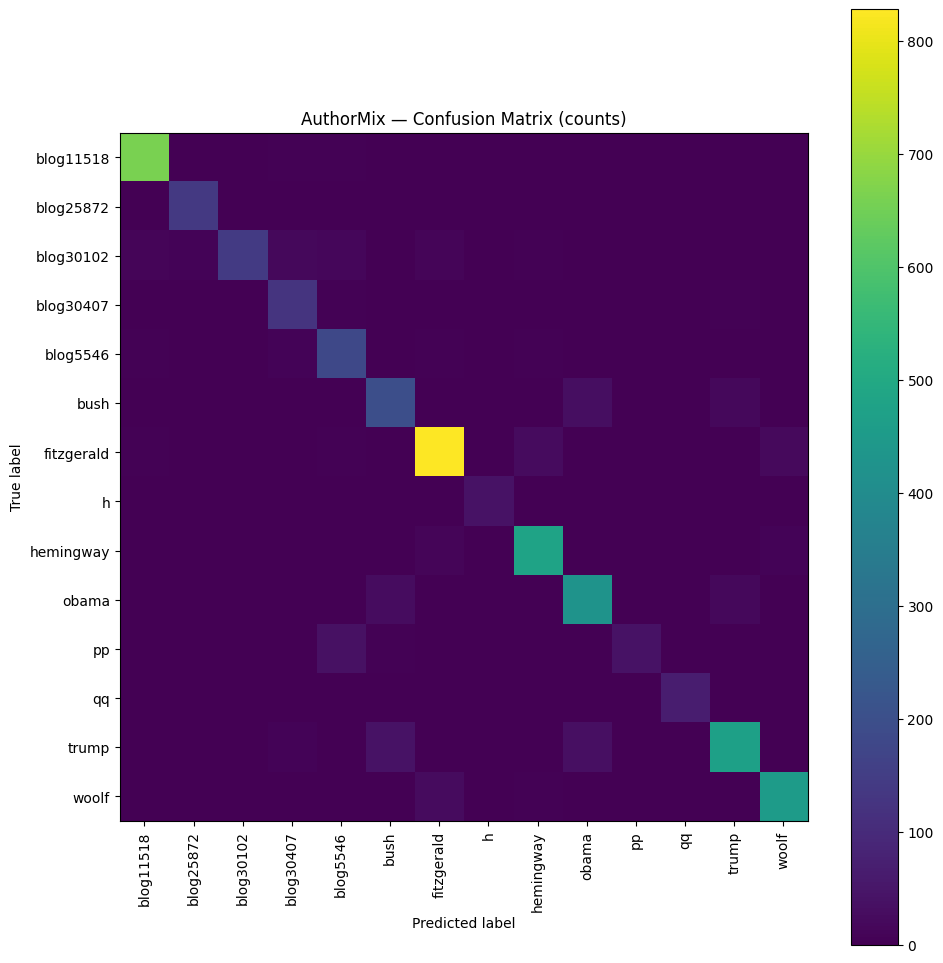

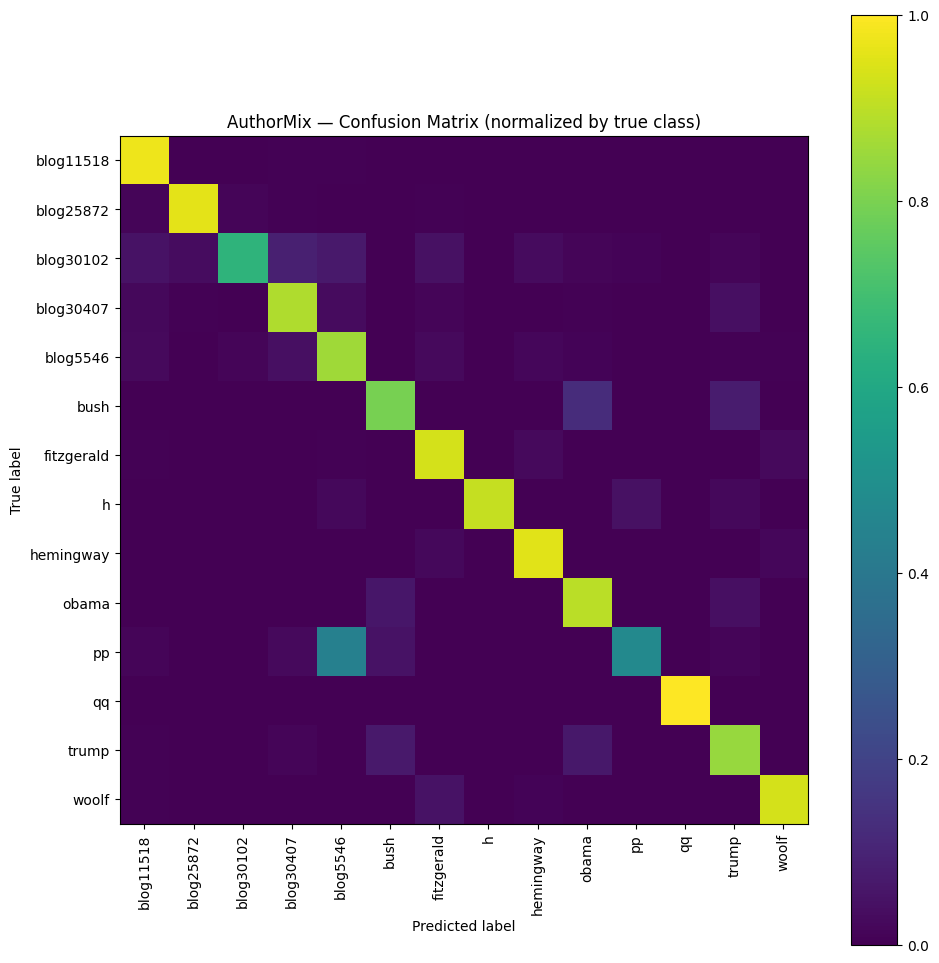

Saved confusion matrix images to: /content/drive/MyDrive/ap-thesis/runs/results/


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
os.makedirs(f"{RUNS_ROOT}/results", exist_ok=True)

labels = np.arange(len(names))
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names)
disp.plot(include_values=False, xticks_rotation=90, ax=plt.gca())
plt.title("AuthorMix — Confusion Matrix (counts)")
plt.tight_layout()
plt.savefig(f"{RUNS_ROOT}/results/authormix_confusion_counts_seed{best_am['seed']}.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=names)
disp.plot(include_values=False, xticks_rotation=90, ax=plt.gca())
plt.title("AuthorMix — Confusion Matrix (normalized by true class)")
plt.tight_layout()
plt.savefig(f"{RUNS_ROOT}/results/authormix_confusion_norm_seed{best_am['seed']}.png", dpi=200)
plt.show()

print("Saved confusion matrix images to:", f"{RUNS_ROOT}/results/")

,class,precision,recall,f1,support
10,pp,0.851064,0.470588,0.606061,85.0
5,bush,0.738007,0.796813,0.766284,251.0
2,blog30102,0.946309,0.649770,0.770492,217.0
4,blog5546,0.720000,0.857143,0.782609,210.0
3,blog30407,0.736842,0.881119,0.802548,143.0
9,obama,0.846614,0.894737,0.870010,475.0
12,trump,0.900763,0.845878,0.872458,558.0
13,woolf,0.934426,0.934426,0.934426,488.0
6,fitzgerald,0.940909,0.935593,0.938244,885.0
8,hemingway,0.925000,0.954365,0.939453,504.0


Saved per-class report to: /content/drive/MyDrive/ap-thesis/runs/results/authormix_per_class_report_seed11.csv


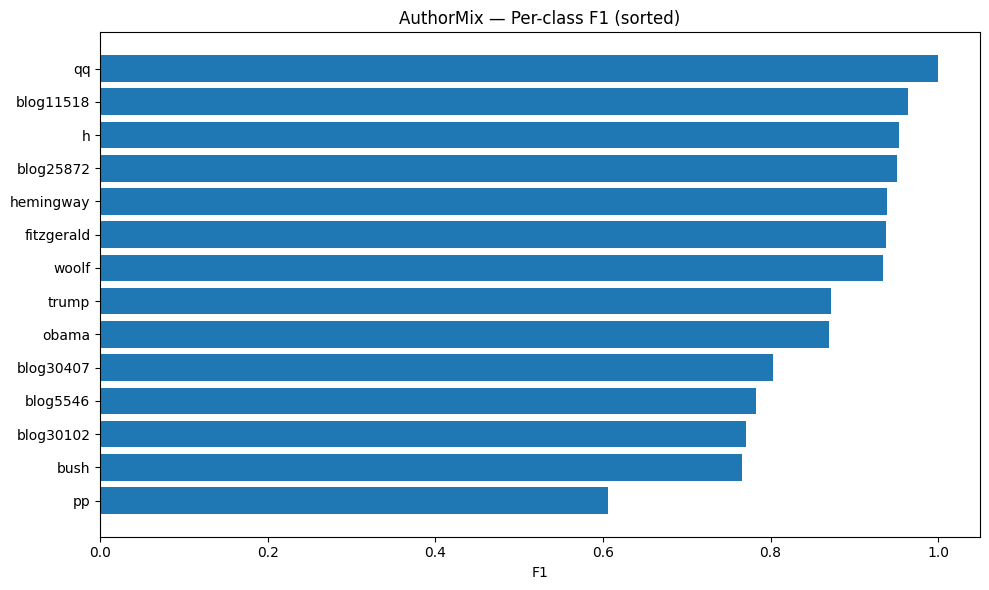

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true, y_pred,
    target_names=names,
    output_dict=True,
    zero_division=0
)

df_rep = pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})
df_classes = df_rep[df_rep["class"].isin(names)].copy()
df_classes = df_classes.rename(columns={"f1-score": "f1"})
df_classes = df_classes.sort_values("f1", ascending=True)

display(df_classes[["class", "precision", "recall", "f1", "support"]])

out_csv = f"{RUNS_ROOT}/results/authormix_per_class_report_seed{best_am['seed']}.csv"
df_classes.to_csv(out_csv, index=False)
print("Saved per-class report to:", out_csv)

# Bar chart: F1 per author (sorted)
plt.figure(figsize=(10, 6))
plt.barh(df_classes["class"], df_classes["f1"])
plt.title("AuthorMix — Per-class F1 (sorted)")
plt.xlabel("F1")
plt.tight_layout()
plt.savefig(f"{RUNS_ROOT}/results/authormix_per_class_f1_seed{best_am['seed']}.png", dpi=200)
plt.show()


In [ ]:
pairs = []
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0:
            pairs.append({
                "true_class": names[i],
                "pred_class": names[j],
                "count": int(cm[i, j]),
                "row_frac": float(cm_norm[i, j])
            })

df_conf = pd.DataFrame(pairs).sort_values(["count", "row_frac"], ascending=False)

display(df_conf.head(25))

out_csv = f"{RUNS_ROOT}/results/authormix_top_confusions_seed{best_am['seed']}.csv"
df_conf.to_csv(out_csv, index=False)
print("Saved top confusions to:", out_csv)

,true_class,pred_class,count,row_frac
64,trump,bush,39,0.069892
58,pp,blog5546,37,0.435294
65,trump,obama,35,0.062724
35,bush,obama,32,0.127490
53,obama,bush,28,0.058947
39,fitzgerald,hemingway,24,0.027119
68,woolf,fitzgerald,23,0.047131
41,fitzgerald,woolf,21,0.023729
14,blog30102,blog30407,19,0.087558
36,bush,trump,19,0.075697


Saved top confusions to: /content/drive/MyDrive/ap-thesis/runs/results/authormix_top_confusions_seed11.csv


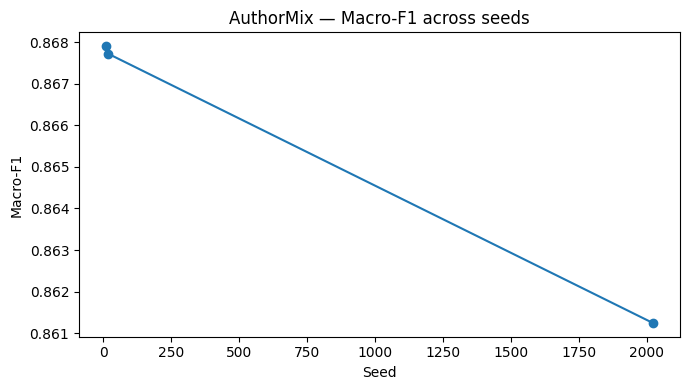

In [ ]:
am_df = pd.read_csv(f"{RUNS_ROOT}/results/authormix_seeds.csv")

plt.figure(figsize=(7, 4))
plt.plot(am_df["seed"], am_df["eval_f1_macro"], marker="o")
plt.title("AuthorMix — Macro-F1 across seeds")
plt.xlabel("Seed")
plt.ylabel("Macro-F1")
plt.tight_layout()
plt.savefig(f"{RUNS_ROOT}/results/authormix_macro_f1_by_seed.png", dpi=200)
plt.show()


In [ ]:
def get_val_predictions(trainer, val_ds, label_col="label"):
    pred = trainer.predict(val_ds)
    logits = pred.predictions
    y_pred = np.argmax(logits, axis=1)
    y_true = np.array(val_ds[label_col])
    probs = (np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True))
    conf = probs.max(axis=1)
    return y_true, y_pred, conf, logits

def per_class_accuracy(y_true, y_pred, label_names=None):
    cm = confusion_matrix(y_true, y_pred)
    acc = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)
    out = pd.DataFrame({
        "class_id": np.arange(len(acc)),
        "class_name": label_names if label_names is not None else np.arange(len(acc)),
        "accuracy_in_true_class": acc,
        "support": cm.sum(axis=1)
    })
    return out, cm